# Q-Learning 迷宫学习作业
========================
本作业将引导你实现一个完整的 Q-Learning 算法来让智能体（Agent）学习如何走出迷宫。

**作业目标:**
智能体（红色方块）需要自主学习，以找到从起点 `[0,0]` 到达黄色目标点 `[2,2]` 的最优路径，同时必须避开黑色的陷阱方块。

**作业分为四个核心部分：**
1.  **Part 1: 了解迷宫环境** - 我们会先定义迷宫的规则，并实现一个随机移动的策略作为对比基线。
2.  **Part 2: 实现 Q-Learning 算法核心** - 你将构建智能体的“大脑”，即 Q-Table，并实现决策和学习的逻辑。
3.  **Part 3: 训练智能体并进行测试** - 你将编写训练循环，让智能体在环境中不断试错和学习，并最终测试其学习成果。
4.  **Part 4: 结果可视化与分析** - 我们提供了可视化函数，帮助你直观地理解智能体的学习成果，例如它的决策地图和找到的最优路径。

## 预备工作：导入必要的库

首先，我们需要导入一些必要的 Python 库：
- `numpy` 和 `pandas` 用于数据处理，特别是 `pandas` 的 DataFrame 非常适合用来构建 Q-Table。
- `matplotlib` 用于将迷宫的状态和学习结果可视化。
- `IPython.display` 的 `clear_output` 用于在 Jupyter Notebook 中创建动态更新的动画效果。
- `time` 用于在动画中增加短暂延时，方便观察。

In [1]:
import numpy as np                          # 导入 NumPy 库并简写为 np，用于数值计算和数组操作
import pandas as pd                         # 导入 pandas 库并简写为 pd，用其 DataFrame 构建 Q-Table
import matplotlib.pyplot as plt             # 导入 matplotlib 的 pyplot 模块并简写为 plt，用于绘图可视化
from IPython.display import clear_output    # 导入 clear_output，用于清除旧输出实现 Notebook 动画效果
from matplotlib.patches import Patch        # 导入 Patch，用于在图例中创建带颜色的色块
import time                                 # 导入 time 库，用于在动画中增加短暂延时方便观察

# 设置 Matplotlib 支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']   # 将绘图默认字体设为 SimHei（黑体），使中文标题/标签能正常显示

## Part 1: 了解迷宫环境 (`GridEnv`)

在强化学习中，**环境（Environment）** 是智能体进行交互和学习的世界。我们需要创建一个类来定义这个世界的所有规则。

我们的 `GridEnv` 类需要包含以下核心功能：
- **`__init__(self)`**: 初始化迷宫的布局，包括陷阱、目标和智能体的起始位置。
- **`reset(self)`**: 重置环境，让智能体回到起点，开始新一轮的探索。
- **`step(self, action)`**: 执行一个动作。这是环境最核心的函数，它会告诉我们执行动作后，智能体的新位置（`next_state`）、获得的奖励（`reward`）以及游戏是否结束（`done`）。
- **`render(self)`**: 将当前迷宫的状态（智能体、陷阱、目标的位置）用图形化的方式显示出来。

In [2]:
class GridEnv:
    """
    迷宫环境类
    
    迷宫布局（4x4 网格）：
    - 红色方块：智能体（agent）
    - 黑色方块：陷阱（hell），奖励 = -1
    - 黄色圆圈：目标（goal），奖励 = +1
    - 白色方块：普通地面，奖励 = 0
    """
    
    # ===== 环境参数（类属性，所有实例共享） =====
    UNIT = 40      # 每个网格的像素大小
    MAZE_H = 4     # 迷宫高度（行数）
    MAZE_W = 4     # 迷宫宽度（列数）
    
    def __init__(self):                                       # 构造方法：创建环境实例时自动调用
        """初始化迷宫环境"""
        self.action_space = ['up', 'down', 'right', 'left']   # 定义四个可选动作的名称
        self.n_actions = len(self.action_space)               # 动作总数（=4）
        
        # 定义特殊位置
        self.goal_pos = [2, 2]                                # 目标位置（第 2 行第 2 列）
        self.hell_positions = [[1, 2], [2, 1]]                # 两个陷阱的位置（用列表保存）
        
        self.agent_pos = None                                 # 智能体位置，先初始化为 None
        self.reset()                                          # 调用 reset 把智能体放到起点
    
    def reset(self):                                          # 重置环境的方法
        """
        重置环境到初始状态
        
        返回:
            初始状态（智能体位置）
        """
        self.agent_pos = [0, 0]                               # 智能体从左上角 [0,0] 开始
        return self.agent_pos.copy()                          # 返回位置的副本（避免外部直接改动内部状态）
    
    def step(self, action):                                   # 执行动作的方法（环境最核心的函数）
        """
        执行一个动作，返回新状态、奖励和是否结束
        
        参数:
            action: 动作编号（0=上, 1=下, 2=右, 3=左）
            
        返回:
            next_state: 新状态（新位置）
            reward: 获得的奖励
            done: 是否到达终止状态
        """
        row, col = self.agent_pos                             # 解包当前智能体所在的行、列坐标
        
        # 根据动作更新位置（注意边界检查：不能走出迷宫）
        if action == 0 and row > 0:                           # 动作 0=上：且不在最上一行时
            row -= 1                                          # 行号减 1（向上移动一格）
        elif action == 1 and row < self.MAZE_H - 1:           # 动作 1=下：且不在最下一行时
            row += 1                                          # 行号加 1（向下移动一格）
        elif action == 2 and col < self.MAZE_W - 1:           # 动作 2=右：且不在最右一列时
            col += 1                                          # 列号加 1（向右移动一格）
        elif action == 3 and col > 0:                         # 动作 3=左：且不在最左一列时
            col -= 1                                          # 列号减 1（向左移动一格）
        
        self.agent_pos = [row, col]                           # 把更新后的位置写回智能体位置
        
        # 计算奖励和是否结束
        if self.agent_pos == self.goal_pos:                   # 判断是否到达目标
            reward, done = 1, True                            # 到达目标：奖励 +1，游戏结束
        elif self.agent_pos in self.hell_positions:           # 判断是否掉入陷阱
            reward, done = -1, True                           # 掉入陷阱：奖励 -1，游戏结束
        else:                                                 # 其他情况（普通地面）
            reward, done = 0, False                           # 普通地面：奖励 0，游戏继续
        
        return self.agent_pos.copy(), reward, done            # 返回新状态、奖励、是否结束
    
    def render(self, mode='训练', episode=0, steps=0, total_reward=0):   # 可视化当前迷宫状态的方法
        """
        使用 matplotlib 可视化当前迷宫状态
        
        参数:
            mode: 模式（'训练' 或 '测试'）
            episode: 当前回合数
            steps: 当前步数
            total_reward: 累计奖励
        """
        # 创建白色背景网格（H 行 × W 列，每个格子用 RGB 三通道颜色表示）
        grid = np.ones((self.MAZE_H, self.MAZE_W, 3), dtype=np.float32)
        
        # 绘制陷阱（黑色）
        for hell in self.hell_positions:                      # 遍历每个陷阱位置
            grid[hell[0], hell[1]] = [0, 0, 0]                # 把该格子颜色设为黑色 [0,0,0]
        
        # 绘制目标（黄色）
        grid[self.goal_pos[0], self.goal_pos[1]] = [1, 1, 0]  # 把目标格子设为黄色 [1,1,0]
        
        # 绘制智能体（红色）
        r, c = self.agent_pos                                 # 解包智能体的行、列坐标
        grid[r, c] = [1, 0, 0]                                # 把智能体所在格子设为红色 [1,0,0]
        
        # 显示图像
        clear_output(wait=True)                               # 清除上一次的输出，实现动态更新动画
        plt.figure(figsize=(7, 6))                            # 新建一个 7×6 英寸的绘图窗口
        plt.imshow(grid, extent=[0, self.MAZE_W, 0, self.MAZE_H], origin='upper')   # 显示网格图像，原点在左上角
        plt.grid(True, color='gray', linewidth=1)             # 显示灰色网格线
        plt.xticks(range(self.MAZE_W + 1))                    # 设置 x 轴刻度（0~4）
        plt.yticks(range(self.MAZE_H + 1))                    # 设置 y 轴刻度（0~4）
        
        # 构建标题，显示详细信息
        title = f'Q-Learning 迷宫学习 - {mode}模式\n'          # 标题第一行：显示当前模式
        title += f'回合: {episode} | 步数: {steps} | 累计奖励: {total_reward:+d}'   # 追加回合/步数/奖励信息
        plt.title(title, fontsize=12, fontweight='bold')      # 设置标题的字号与加粗样式
        
        # 添加图例说明
        legend_elements = [                                   # 构建图例元素列表
            Patch(facecolor='red', label='智能体'),            # 红色块 → 智能体
            Patch(facecolor='yellow', label='目标 (+1)'),      # 黄色块 → 目标
            Patch(facecolor='black', label='陷阱 (-1)'),       # 黑色块 → 陷阱
            Patch(facecolor='white', edgecolor='gray', label='地面 (0)')   # 白色块 → 普通地面
        ]
        plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1))   # 在图右侧放置图例
        
        plt.tight_layout()                                    # 自动调整布局，避免元素重叠
        plt.show()                                            # 显示图像
        time.sleep(0.1)                                       # 延时 0.1 秒，方便观察动画过程

### 【作业任务 1】: 实现随机策略

为了感受一下环境是如何工作的，并为我们之后的 Q-Learning 算法建立一个“最差表现”的基准，我们先来实现一个完全随机的策略。这个策略非常简单：在每一步，智能体都从所有可能的动作中随机选择一个来执行。

In [ ]:
def random_walk_demo(env, max_steps=50):                 # 定义随机策略演示函数，env 为环境实例，max_steps 为最大步数
    """
    演示随机策略在迷宫中的表现
    
    【作业任务 1】：实现随机策略
    """
    print("=" * 50)                                      # 打印 50 个等号作为分隔线
    print("随机策略演示")                                 # 打印标题
    print("=" * 50)                                      # 再打印一条分隔线
    
    state = env.reset()                                  # 重置环境，让智能体回到起点 [0,0]
    total_reward = 0                                     # 累计奖励，初始为 0
    steps = 0                                            # 步数计数器，初始为 0
    
    print("智能体开始随机移动...")                        # 提示开始移动
    
    while steps < max_steps:                             # 最多走 max_steps 步，防止无限循环
        # 可视化当前状态
        env.render(mode='随机策略', episode=1, steps=steps, total_reward=total_reward)   # 渲染当前画面
        
        # ==================== 【补全代码 1】 ====================
        # 随机选择一个动作（0-3）：np.random.choice 从给定序列中均匀随机取一个元素
        # range(env.n_actions) = range(4) → 得到动作编号 [0,1,2,3]
                                                         # 从 4 个动作中随机选一个（随机策略）
        
        # 执行动作，获取下一个状态、奖励和是否结束的标志
        # next_state: 智能体移动后的新位置（例如 [0, 1]）
        # reward:     该步获得的奖励（普通地面 0 / 到达目标 +1 / 掉入陷阱 -1）
        # done:       是否到达终止状态（到达目标或掉入陷阱时为 True）
                                                         # 在环境中执行该动作，得到反馈
        # =========================================================
        
        # 更新统计信息
        state = next_state                               # 把新位置作为下一次循环的当前位置
        total_reward += reward                           # 累加本步奖励
        steps += 1                                       # 步数加 1
        
        # 检查是否结束
        if done:                                         # 若到达目标或掉入陷阱
            env.render(mode='随机策略', episode=1, steps=steps, total_reward=total_reward)   # 渲染最终画面
            break                                        # 跳出循环，结束本次演示
    
    print(f"\n随机策略结果：步数={steps}, 总奖励={total_reward:+d}")   # 打印随机策略的步数和累计奖励
    print("可以看到，随机策略效率很低，经常撞墙或掉入陷阱")          # 打印结论提示
    print()                                              # 打印一个空行，分隔输出

## Part 2: 实现 Q-Learning 算法核心 (`QLearningTable`)

现在，我们来构建智能体的“大脑”——`QLearningTable` 类。这个类的核心是一张 **Q-Table**，它记录了在每个状态（`state`）下，执行每个动作（`action`）所能带来的预期未来总奖励，我们称之为 Q 值。

这个类需要实现 Q-Learning 算法的两个关键部分：
1.  **`choose_action(self, state)`**: **决策**。根据当前状态，并利用 Q-Table 中的知识来选择一个动作。这里我们会使用 **ε-贪婪（Epsilon-Greedy）策略**：
    - 以 `ε` 的概率进行**利用（Exploitation）**：选择当前状态下 Q 值最大的动作。
    - 以 `1-ε` 的概率进行**探索（Exploration）**：随机选择一个动作，以发现更多可能性。

2.  **`learn(self, state, action, reward, next_state)`**: **学习**。在执行一个动作并得到环境的反馈（奖励 `reward` 和新状态 `next_state`）后，使用 **Q-Learning 的核心更新公式**来更新 Q-Table 中对应的 Q 值：
   $$ Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right] $$
   其中 `s` 是当前状态，`a` 是执行的动作，`r` 是奖励，`s'` 是下一个状态，`α` 是学习率，`γ` 是折扣因子。

In [ ]:
class QLearningTable:                                     # 定义 Q-Learning 智能体类（智能体的"大脑"）
    def __init__(self, actions, learning_rate=0.01, reward_decay=0.9, e_greedy=0.9):   # 构造方法，初始化超参数
        self.actions = actions                            # 保存可选动作集合（这里为 [0,1,2,3]）
        self.lr = learning_rate                           # 学习率 α，控制每次更新向目标值靠近的幅度
        self.gamma = reward_decay                         # 折扣因子 γ，衡量未来奖励的重要性
        self.epsilon = e_greedy                           # ε-贪婪策略参数（这里表示"利用"的概率）
        
        # 初始化一个空的 Q-Table (使用 pandas DataFrame)
        # 每一行对应一个状态，每一列对应一个动作，单元格存储该状态-动作对的 Q 值
        self.q_table = pd.DataFrame(columns=self.actions, dtype=np.float64)   # 创建以动作为列名的空表

    def choose_action(self, state):                       # 决策方法：根据当前状态选择一个动作
        """【作业任务 2】: 实现 ε-贪婪策略来选择动作"""
        self._check_state_exist(state)                    # 确保当前状态在 Q-Table 中已有对应的行
        
        # ==================== 【请在这里补全代码 2】 ====================
        # 1. 生成一个 0-1 之间的随机数，用于判断本次是"利用"还是"探索"
                                                          # 若随机数小于 epsilon（概率为 epsilon）
            # 2. 随机数 < epsilon，进行"利用"（Exploitation）：
            #    取出当前 state 在 Q-Table 中对应的那一行（所有动作的 Q 值）
                                                          # 取出该状态在 Q-Table 中整行的 Q 值
            #    选出该行中 Q 值最大的动作；若有多个并列最大值，从中随机选一个，
            #    避免每次总是选到第一个最大值的动作
                                                                                                   # 随机选一个最大 Q 值的动作
                                                          # 否则（概率 1-epsilon）
            # 3. 否则进行"探索"（Exploration）：从所有动作中随机选择一个，
            #    以便探索未知的状态-动作对，发现更多可能性
                                                          # 从所有动作中随机选一个
        # =========================================================
        
        return action                                     # 返回选中的动作编号

    def learn(self, state, action, reward, next_state):   # 学习方法：根据一次经验更新 Q-Table
        """【作业任务 3】: 实现 Q-Learning 更新规则"""
        self._check_state_exist(next_state)               # 确保下一状态在 Q-Table 中已有对应的行
        
        # ==================== 【请在这里补全代码 3】 ====================
        # 1. 获取"预测 Q 值"：Q(s,a)，即当前状态下执行该动作的估计价值
                                                          # 从 Q-Table 中取出 Q(s,a)
        
        # 2. 计算"目标 Q 值" q_target
                                                          # 如果下一状态不是终止状态
            # 如果 next_state 不是终止状态：目标值 = 立即奖励 + γ × 下一状态的最大 Q 值
                                                                                     # r + γ·max Q(s',a')
                                                          # 如果下一状态是终止状态（'terminal'）
            # 如果 next_state 是终止状态（到达目标或掉入陷阱），没有未来，
            # 目标值就是立即奖励本身
                                                          # 终止状态的目标值就是奖励 r
        
        # 3. 按 Q-Learning 更新公式更新 Q-Table：
        #    Q(s,a) ← Q(s,a) + α × [q_target - q_predict]
        #    即用学习率 α 控制本次向目标值靠近的幅度
                                                                              # 更新 Q(s,a) 的值
        # =========================================================

    def _check_state_exist(self, state):                  # 私有方法：检查状态是否在 Q-Table 中
        """检查状态是否存在于Q表中，如果不存在则添加新行"""
        if state not in self.q_table.index:               # 若该状态还没有对应的行
            new_row = pd.DataFrame(                       # 构造一行全 0 的 Q 值（新状态初始 Q 值均为 0）
                [[0] * len(self.actions)],                # 行数据：len(actions) 个 0，表示每个动作的初始 Q 值
                columns=self.q_table.columns,             # 列名与 Q-Table 保持一致（动作编号）
                index=[state]                             # 行索引为新加入的状态
            )
            self.q_table = pd.concat([self.q_table, new_row])   # 把新行拼接到 Q-Table 中

--## Part 3: 训练与测试

现在我们已经定义好了环境和智能体，是时候将它们连接起来，开始训练了！

**训练流程** 是一个双层循环：
- **外层循环 (Episodes)**: 代表智能体一次完整的尝试，从起点出发直到游戏结束（掉入陷阱或找到目标）。我们重复进行很多次 Episodes 来积累经验。
- **内层循环 (Steps)**: 在每一次尝试中，智能体执行的一系列步骤。在每一步中，智能体都会：
    1.  选择一个动作 (`choose_action`)
    2.  在环境中执行该动作 (`env.step`)
    3.  从经验中学习 (`learn`)
    4.  进入下一个状态

In [ ]:
def train_agent(episodes=100):                            # 定义训练函数，episodes 为训练回合数
    """【作业任务 4】: 实现完整的训练循环"""
    # 1. 创建环境和智能体实例
    env = GridEnv()                                       # 创建迷宫环境实例
    agent = QLearningTable(actions=list(range(env.n_actions)))   # 创建 Q-Learning 智能体（动作为 0~3）

    # 2. 开始外层循环（episodes）：每个回合智能体从起点出发，直到游戏结束
    for episode in range(episodes):                       # 循环 episodes 次，每个回合都是一次完整尝试
        # 重置环境，获取初始状态
        state = env.reset()                               # 重置环境，智能体回到起点，得到初始状态
        
        # 3. 开始内层循环（steps）：在当前回合内一步一步地走，直到结束
        while True:                                       # 无限循环，直到游戏结束才跳出
            # ==================== 【请在这里补全代码 4】 ====================
            # a. 智能体根据当前状态 state 选择动作 action
            #    （用 str(state) 作为 Q-Table 的行索引，因为 DataFrame 索引需要可哈希的值）
                                                          # 智能体选择动作
            
            # b. 环境执行动作，返回 next_state, reward, done
                                                          # 环境执行动作并反馈结果
            
            # c. 智能体从这次经验中学习，更新 Q-Table
            #    若游戏结束(done)，用字符串 'terminal' 表示终止状态（它没有未来价值）
                                                           # 调用 learn 更新 Q-Table
                                                                       # 终止状态用 'terminal' 表示
            
            # d. 更新当前状态，进入下一轮循环
                                                          # 把新状态作为下一轮的当前状态
            # =========================================================
            
            # 如果游戏结束，则跳出内层循环
            if done:                                      # 若到达目标或掉入陷阱
                break                                     # 跳出内层 while 循环，进入下一回合
    
    # 训练结束后，返回训练好的智能体（含学到的 Q-Table）和环境（供测试与可视化使用）
    return agent, env                                     # 返回智能体和环境

### 测试智能体

训练完成后，我们需要评估智能体的学习效果。测试与训练的主要区别在于，测试时我们希望智能体**只利用（Exploit）** 它学到的最优策略，而不是进行探索。因此，我们会暂时将 `epsilon` 设置为 1.0（或一个非常接近 1 的值），让它总是选择 Q 值最大的动作。

In [6]:
def test_agent(agent, env):                               # 定义测试函数，输入训练好的智能体和环境
    """测试训练好的智能体"""
    # 将 epsilon 设为 1.0，实现纯粹的"利用"策略（始终选择 Q 值最大的动作）
    original_epsilon = agent.epsilon                      # 先保存原始的 epsilon 值
    agent.epsilon = 1.0                                   # 临时改为 1.0，让随机数一定 < 1.0，即总是"利用"
    
    # 重置环境到初始状态，并初始化统计变量
    state = env.reset()                                   # 重置环境，智能体回到起点
    total_reward = 0                                      # 本次测试的累计奖励，初始为 0
    steps = 0                                             # 本次测试的步数，初始为 0
    
    print("\n【测试模式】智能体开始按照学到的策略移动...")   # 打印提示信息
    
    # 测试循环：逻辑与训练类似，但只"利用"不"学习"（不调用 learn）
    while True:                                           # 无限循环，直到游戏结束
        # 可视化当前状态
        env.render(mode='测试', episode=1, steps=steps, total_reward=total_reward)   # 渲染当前画面
        
        # 智能体根据当前状态选择动作（epsilon=1.0，始终贪心选择最大 Q 值动作）
        action = agent.choose_action(str(state))          # 智能体贪心选择动作
        
        # 环境执行动作，返回下一个状态、奖励、是否结束
        next_state, reward, done = env.step(action)       # 环境执行动作并反馈结果
        
        # 更新统计信息
        total_reward += reward                            # 累加本步奖励
        steps += 1                                        # 步数加 1
        state = next_state                                # 把新状态作为下一轮的当前状态
        
        # 如果游戏结束（到达目标或掉入陷阱），渲染最终画面并跳出循环
        if done:                                          # 若游戏结束
            env.render(mode='测试', episode=1, steps=steps, total_reward=total_reward)   # 渲染最终画面
            break                                         # 跳出循环，测试结束
    
    # 输出测试结果
    print(f"\n测试结果：步数={steps}, 累计奖励={total_reward:+d}")   # 打印步数和累计奖励
    if total_reward > 0:                                  # 累计奖励为正，说明到达了目标
        print("✓ 智能体成功找到了目标！")                 # 打印成功信息
    else:                                                 # 累计奖励为负，说明掉入了陷阱
        print("✗ 智能体掉入了陷阱。")                     # 打印失败信息
    
    # 恢复原始的 epsilon 值
    agent.epsilon = original_epsilon                      # 恢复 epsilon，避免影响后续使用
    
    # 返回步数和累计奖励，供主程序使用
    return steps, total_reward                            # 返回测试的步数和累计奖励

## Part 4: 结果可视化与分析

为了更直观地理解 Q-Learning 的学习成果，我们提供了两个可视化函数（无需修改，直接使用即可）：

1.  **`visualize_value_table(agent, env)`**: 
    - **状态价值热力图**: 显示每个格子的价值（V-value），价值越高的格子颜色越“暖”。价值是通过取该状态下所有动作的最大 Q 值得到的 `V(s) = max(Q(s,a))`。
    - **最优策略图**: 用箭头显示在每个格子，智能体最倾向于执行的动作。

2.  **`visualize_learning_path(agent, env)`**:
    - 在迷宫上直接绘制出智能体根据学到的最优策略走出的路径。

In [7]:
def visualize_value_table(agent, env):                    # 定义可视化函数：显示状态价值热力图和最优策略图
    """可视化 V 表（状态价值函数）和策略"""
    # 创建一个 4x4 的数组用于存储每个格子的状态价值 V(s)，先全部初始化为 NaN
    # （NaN 表示该格子是终止状态或尚未学习，稍后会被特殊标注）
    value_map = np.full((env.MAZE_H, env.MAZE_W), np.nan)   # 创建全 NaN 的 4×4 价值数组
    
    # 遍历所有格子，计算每个状态的价值 V(s) = max_a Q(s, a)
    for i in range(env.MAZE_H):                           # 遍历每一行 i
        for j in range(env.MAZE_W):                       # 遍历每一列 j
            state_str = str([i, j])                       # 状态的字符串形式（Q-Table 索引）
            if state_str in agent.q_table.index:          # 只处理 Q-Table 中已存在的状态
                value_map[i, j] = agent.q_table.loc[state_str, :].max()   # 取该状态所有动作的最大 Q 值作为 V
    
    # 动作编号 → 箭头方向向量的映射（用于策略图）
    # 0=上(行减1), 1=下(行加1), 2=右(列加1), 3=左(列减1)
    action_vectors = {0: (0, -0.4),                       # 动作 0=上：箭头指向 (0, -0.4)
                      1: (0, 0.4),                        # 动作 1=下：箭头指向 (0, 0.4)
                      2: (0.4, 0),                        # 动作 2=右：箭头指向 (0.4, 0)
                      3: (-0.4, 0)}                       # 动作 3=左：箭头指向 (-0.4, 0)
    
    plt.figure(figsize=(12, 5))                           # 新建一个 12×5 英寸的绘图窗口（含两个子图）
    
    # ---- 子图 1：状态价值热力图 ----
    plt.subplot(1, 2, 1)                                  # 在 1 行 2 列布局中，选择第 1 个子图
    im = plt.imshow(value_map, cmap='YlOrRd')             # 画热力图，颜色越暖（越红）表示价值越高
    plt.colorbar(im, label='状态价值 V(s)')               # 添加颜色条（图例），标注数值含义
    plt.title('状态价值热力图', fontsize=13, fontweight='bold')   # 设置子图标题
    for i in range(env.MAZE_H):                           # 遍历每一行 i
        for j in range(env.MAZE_W):                       # 遍历每一列 j
            if not np.isnan(value_map[i, j]):             # 如果该格子有 V 值（不是 NaN）
                plt.text(j, i, f'{value_map[i, j]:.2f}', ha='center', va='center', fontsize=9)   # 在格子上标注 V 值
    for hell in env.hell_positions:                       # 遍历每个陷阱位置
        plt.text(hell[1], hell[0], '×', ha='center', va='center', fontsize=20, color='black')   # 用 × 标注陷阱
    plt.text(env.goal_pos[1], env.goal_pos[0], '★',       # 用 ★ 标注目标
             ha='center', va='center', fontsize=20, color='gold')
    plt.xticks(range(env.MAZE_W))                         # 设置 x 轴刻度（列号 0~3）
    plt.yticks(range(env.MAZE_H))                         # 设置 y 轴刻度（行号 0~3）
    
    # ---- 子图 2：最优策略图（用箭头表示每个格子的最优动作）----
    plt.subplot(1, 2, 2)                                  # 在 1 行 2 列布局中，选择第 2 个子图
    plt.title('最优策略图', fontsize=13, fontweight='bold')   # 设置子图标题
    plt.imshow(np.ones((env.MAZE_H, env.MAZE_W, 3)))      # 画一个白色背景网格
    for i in range(env.MAZE_H):                           # 遍历每一行 i
        for j in range(env.MAZE_W):                       # 遍历每一列 j
            state_str = str([i, j])                       # 状态的字符串形式
            if state_str in agent.q_table.index:          # 对每个已学习状态
                best_action = agent.q_table.loc[state_str, :].idxmax()   # 找最大 Q 值对应的动作
                dx, dy = action_vectors[best_action]      # 得到该动作的箭头方向
                plt.arrow(j, i, dx, dy, head_width=0.15, head_length=0.15,
                          fc='blue', ec='blue', length_includes_head=True)   # 绘制蓝色箭头表示最优动作
    for hell in env.hell_positions:                       # 遍历每个陷阱位置
        plt.text(hell[1], hell[0], '×', ha='center', va='center', fontsize=20, color='black')   # 用 × 标注陷阱
    plt.text(env.goal_pos[1], env.goal_pos[0], '★',       # 用 ★ 标注目标
             ha='center', va='center', fontsize=20, color='gold')
    plt.xlim(-0.5, env.MAZE_W - 0.5)                      # 固定 x 轴范围
    plt.ylim(env.MAZE_H - 0.5, -0.5)                      # 反转 y 轴，让 [0,0] 显示在左上角
    plt.xticks(range(env.MAZE_W))                         # 设置 x 轴刻度（列号 0~3）
    plt.yticks(range(env.MAZE_H))                         # 设置 y 轴刻度（行号 0~3）
    plt.gca().set_aspect('equal')                         # 保持格子为正方形（纵横比 1:1）
    
    plt.tight_layout()                                    # 自动调整子图布局，避免重叠
    plt.show()                                            # 显示图像


def visualize_learning_path(agent, env):                  # 定义可视化函数：显示智能体学到的最优路径
    """可视化学习到的最优路径"""
    # 临时将 epsilon 设为 1.0，让智能体走纯贪心（最优）策略来得到路径
    original_epsilon = agent.epsilon                      # 先保存原始 epsilon
    agent.epsilon = 1.0                                   # 临时改为 1.0（纯利用）
    
    # 从起点开始，用列表记录按顺序访问过的每个位置
    state = env.reset()                                   # 重置环境，智能体回到起点
    path = [tuple(state)]                                 # 初始把起点加入路径（转为元组便于比较）
    
    max_steps = env.MAZE_H * env.MAZE_W                   # 最多走 16 步，防止意外死循环
    for _ in range(max_steps):                            # 循环最多 max_steps 步
        action = agent.choose_action(str(state))          # 智能体贪心选择动作
        next_state, reward, done = env.step(action)       # 环境执行动作并反馈结果
        path.append(tuple(next_state))                    # 把新位置加入路径
        state = next_state                                # 更新当前状态
        if done:                                          # 到达目标或陷阱则停止
            break                                         # 跳出循环
    
    agent.epsilon = original_epsilon                      # 恢复原始 epsilon
    
    # 构建迷宫背景图：白色地面、黑色陷阱、黄色目标
    grid = np.ones((env.MAZE_H, env.MAZE_W, 3), dtype=np.float32)   # 创建白色背景网格
    for hell in env.hell_positions:                       # 遍历每个陷阱位置
        grid[hell[0], hell[1]] = [0, 0, 0]                # 陷阱格子设为黑色
    grid[env.goal_pos[0], env.goal_pos[1]] = [1, 1, 0]    # 目标格子设为黄色
    
    plt.figure(figsize=(6, 6))                            # 新建一个 6×6 英寸的绘图窗口
    plt.imshow(grid, origin='upper')                      # 显示迷宫背景，原点在左上角
    
    # 将路径点 (行,列) 转换为绘图坐标 (列,行)，用红线把路径连起来
    xs = [p[1] for p in path]                             # 提取每个路径点的列号作为 x 坐标
    ys = [p[0] for p in path]                             # 提取每个路径点的行号作为 y 坐标
    plt.plot(xs, ys, marker='o', color='red', linewidth=2, markersize=10,
             markerfacecolor='red', markeredgecolor='white', label='学习路径')   # 用红色折线绘制路径
    
    # 标注起点与目标
    plt.text(0, 0, '起点', ha='center', va='center', color='white',
             fontsize=11, fontweight='bold')              # 在 [0,0] 标注"起点"
    plt.text(env.goal_pos[1], env.goal_pos[0], '目标', ha='center', va='center',
             color='black', fontsize=11, fontweight='bold')   # 在目标位置标注"目标"
    
    plt.title('Q-Learning 学习到的最优路径', fontsize=13, fontweight='bold')   # 设置标题
    plt.xticks(range(env.MAZE_W))                         # 设置 x 轴刻度
    plt.yticks(range(env.MAZE_H))                         # 设置 y 轴刻度
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))   # 在图右侧放置图例
    plt.tight_layout()                                    # 自动调整布局
    plt.show()                                            # 显示图像
    
    # 打印路径信息
    print("最优路径（按访问顺序）:", path)                 # 打印访问路径
    if path[-1] == tuple(env.goal_pos):                   # 若最后一步是目标，说明成功
        print(f"✓ 智能体在 {len(path)-1} 步内成功到达目标！")   # 打印成功信息
    else:                                                 # 否则掉入了陷阱
        print("✗ 智能体掉入了陷阱，未能到达目标。")       # 打印失败信息

## 主程序：将所有部分串联起来

最后，我们将在主程序块中按顺序执行所有步骤：
1.  运行 `random_walk_demo()` 感受随机策略。
2.  运行 `train_agent()` 训练我们的智能体。
3.  运行 `test_agent()` 检验训练成果。
4.  调用 `visualize_...` 函数，将学习结果可视化，进行分析。

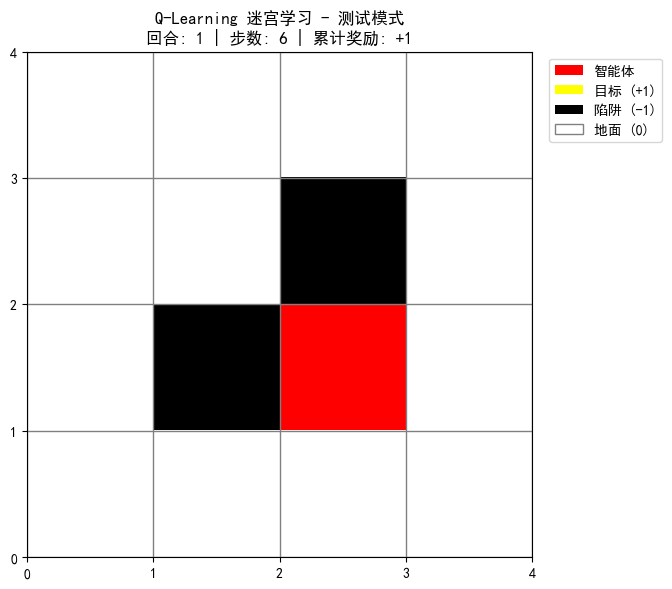


测试结果：步数=6, 累计奖励=+1
✓ 智能体成功找到了目标！

【Step 5】可视化学习结果...


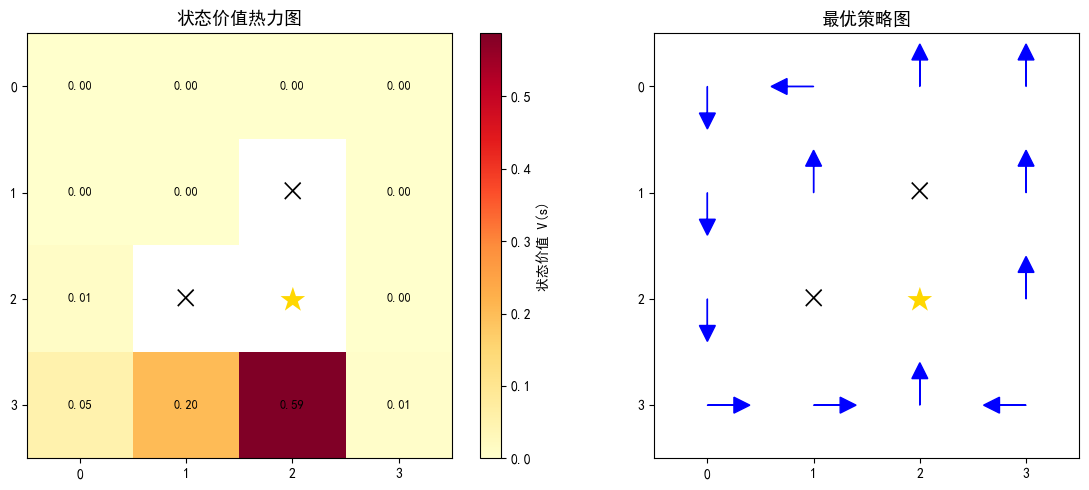

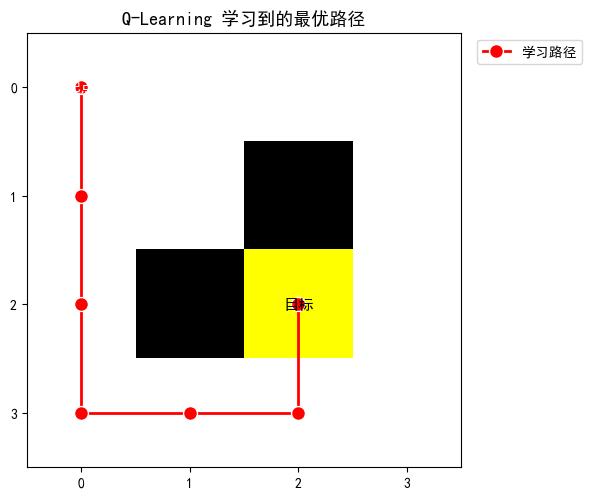

最优路径（按访问顺序）: [(0, 0), (1, 0), (2, 0), (3, 0), (3, 1), (3, 2), (2, 2)]
✓ 智能体在 6 步内成功到达目标！


In [8]:
if __name__ == "__main__":                                # 主程序入口：当本文件作为脚本直接运行时执行
    # 注意：请先将上面所有 cell 中被省略的代码
    #      用您收到的完整 .py 文件中的代码填充，然后再运行此 cell
    
    # Step 1: 体验随机策略
    print("\n【Step 1】体验随机策略...")                  # 打印步骤提示
    env = GridEnv()                                       # 创建一个迷宫环境实例
    random_walk_demo(env)                                 # 运行随机策略演示，作为对比基线
    
    # Step 2-4: 训练、测试和可视化
    print("\n【Step 2-4】开始训练、测试和可视化...")      # 打印步骤提示
    
    # 训练智能体（跑 100 个回合）
    trained_agent, grid_env = train_agent(episodes=100)   # 训练智能体，返回训练好的智能体和环境
    
    # 测试智能体
    test_agent(trained_agent, grid_env)                   # 用学到的策略测试智能体
    
    # 可视化结果
    print("\n【Step 5】可视化学习结果...")                # 打印步骤提示
    visualize_value_table(trained_agent, grid_env)        # 显示状态价值热力图和最优策略图
    visualize_learning_path(trained_agent, grid_env)      # 显示学到的最优路径